In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
Portfolio = pd.read_csv("Portfolio.csv", index_col=0, parse_dates=True)

In [5]:
Portfolio

,SPY_Return,QQQ_Return,XLE_Return,GLD_Return,TLT_Return
Date,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN
2005-01-04,-0.012295,-0.018396,-0.005159,-0.006530,-0.010535
2005-01-05,-0.006925,-0.006208,-0.004320,-0.001639,0.005338
2005-01-06,0.005071,-0.004943,0.017167,-0.012261,0.000680
2005-01-07,-0.001434,0.005202,-0.007974,-0.007382,0.002261
...,...,...,...,...,...
2026-03-18,-0.014052,-0.014038,-0.001368,-0.032148,-0.005619
2026-03-19,-0.002467,-0.003165,0.015791,-0.042088,0.006076
2026-03-20,-0.014440,-0.018655,-0.000843,-0.031034,-0.019156


In [7]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

In [9]:
Portfolio["Portfolio_Return"] = Portfolio.dot(weights)

In [11]:
Portfolio

,SPY_Return,QQQ_Return,XLE_Return,GLD_Return,TLT_Return,Portfolio_Return
Date,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,-0.012295,-0.018396,-0.005159,-0.006530,-0.010535,-0.010583
2005-01-05,-0.006925,-0.006208,-0.004320,-0.001639,0.005338,-0.002751
2005-01-06,0.005071,-0.004943,0.017167,-0.012261,0.000680,0.001143
2005-01-07,-0.001434,0.005202,-0.007974,-0.007382,0.002261,-0.001865
...,...,...,...,...,...,...
2026-03-18,-0.014052,-0.014038,-0.001368,-0.032148,-0.005619,-0.013445
2026-03-19,-0.002467,-0.003165,0.015791,-0.042088,0.006076,-0.005171
2026-03-20,-0.014440,-0.018655,-0.000843,-0.031034,-0.019156,-0.016825


In [13]:
Portfolio = Portfolio.dropna()
Portfolio

,SPY_Return,QQQ_Return,XLE_Return,GLD_Return,TLT_Return,Portfolio_Return
Date,,,,,,
2005-01-04,-0.012295,-0.018396,-0.005159,-0.006530,-0.010535,-0.010583
2005-01-05,-0.006925,-0.006208,-0.004320,-0.001639,0.005338,-0.002751
2005-01-06,0.005071,-0.004943,0.017167,-0.012261,0.000680,0.001143
2005-01-07,-0.001434,0.005202,-0.007974,-0.007382,0.002261,-0.001865
2005-01-10,0.004717,-0.000519,0.007408,0.002626,0.001580,0.003162
...,...,...,...,...,...,...
2026-03-18,-0.014052,-0.014038,-0.001368,-0.032148,-0.005619,-0.013445
2026-03-19,-0.002467,-0.003165,0.015791,-0.042088,0.006076,-0.005171
2026-03-20,-0.014440,-0.018655,-0.000843,-0.031034,-0.019156,-0.016825


In [15]:
confidence_lvl = [0.95, 0.99]
VaR_Results = {}
for cl in confidence_lvl:
    VaR = np.percentile(Portfolio["Portfolio_Return"] ,  (1 - cl) * 100)
    VaR_Results[f'VaR_{int(cl*100)}'] = VaR

for key, value in VaR_Results.items():
    print(f"{key} :{value:.4f} ({value*100: .2f}%)")

VaR_95 :-0.0120 (-1.20%)
VaR_99 :-0.0231 (-2.31%)


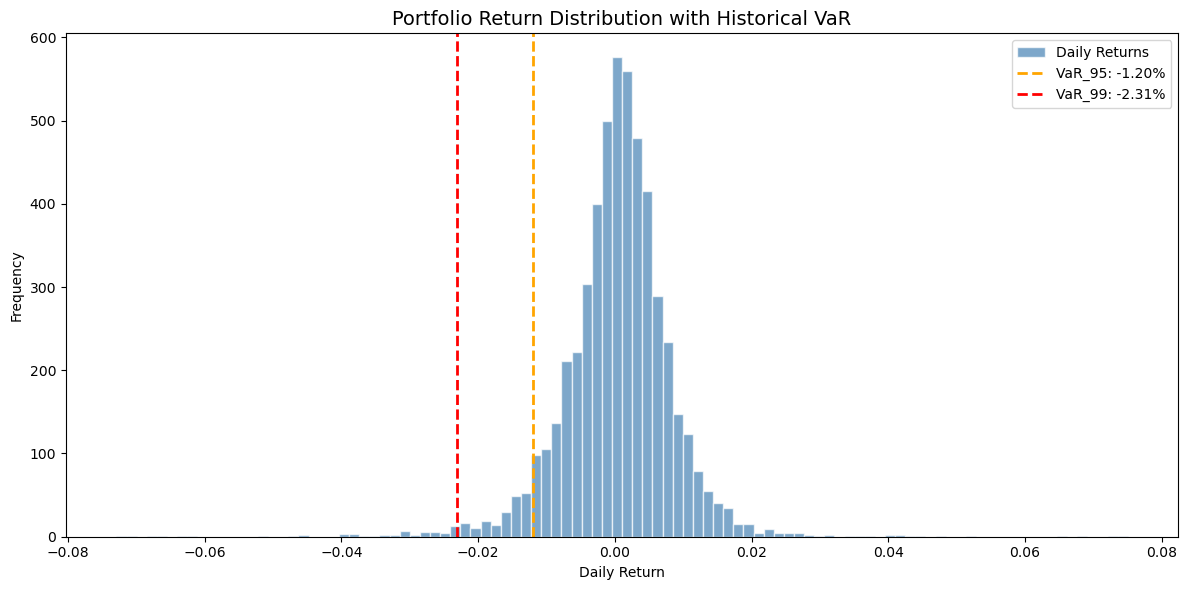

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot return distribution
ax.hist(Portfolio["Portfolio_Return"], bins=100, color='steelblue', 
        alpha=0.7, edgecolor='white', label='Daily Returns')

# Mark VaR lines
colors = {'VaR_95': 'orange', 'VaR_99': 'red'}

for key, value in VaR_Results.items():
    ax.axvline(value, color=colors[key], linewidth=2, 
               linestyle='--', label=f'{key}: {value*100:.2f}%')

ax.set_title('Portfolio Return Distribution with Historical VaR', fontsize=14)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
cVaR_Results = {}

for cl in confidence_lvl:
    VaR = VaR_Results[f'VaR_{int(cl*100)}'] 
    tail_losses = Portfolio["Portfolio_Return"][Portfolio["Portfolio_Return"] <= VaR]
    cVaR = tail_losses.mean()
    cVaR_Results[f'CVaR_{int(cl*100)}'] = cVaR

for key, val in cVaR_Results.items():
    print(f"{key} : {val:.4f} ({val*100:.2f}%)")

CVaR_95 : -0.0197 (-1.97%)
CVaR_99 : -0.0349 (-3.49%)


In [21]:
print("========== Risk Metrics Summary ==========")
print(f"{'Metric':<12} {'95%':>10} {'99%':>10}")
print("-" * 35)
print(f"{'VaR':<12} {VaR_Results['VaR_95']*100:>9.2f}% {VaR_Results['VaR_99']*100:>9.2f}%")
print(f"{'CVaR':<12} {cVaR_Results['CVaR_95']*100:>9.2f}% {cVaR_Results['CVaR_99']*100:>9.2f}%")
print(f"{'Difference':<12} {(cVaR_Results['CVaR_95']-VaR_Results['VaR_95'])*100:>9.2f}% {(cVaR_Results['CVaR_99']-VaR_Results['VaR_99'])*100:>9.2f}%")

========== Risk Metrics Summary ==========
Metric              95%        99%
-----------------------------------
VaR              -1.20%     -2.31%
CVaR             -1.97%     -3.49%
Difference       -0.77%     -1.19%


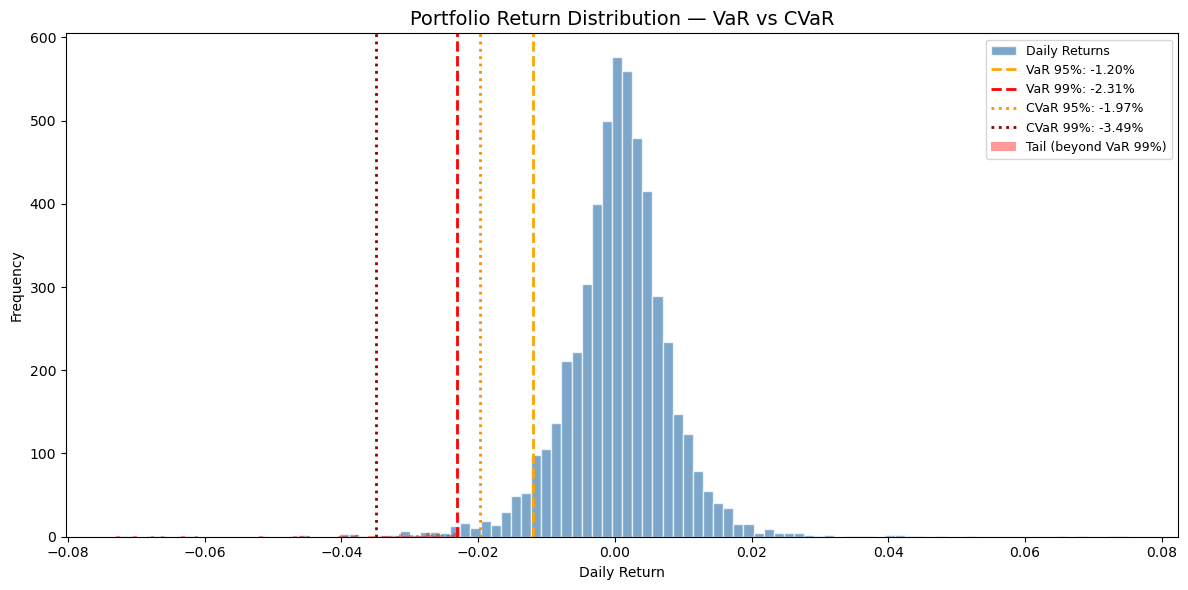

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

# Return distribution
ax.hist(Portfolio["Portfolio_Return"], bins=100, color='steelblue',
        alpha=0.7, edgecolor='white', label='Daily Returns')

# VaR lines (dashed)
ax.axvline(VaR_Results['VaR_95'], color='orange', linewidth=2,
           linestyle='--', label=f"VaR 95%: {VaR_Results['VaR_95']*100:.2f}%")
ax.axvline(VaR_Results['VaR_99'], color='red', linewidth=2,
           linestyle='--', label=f"VaR 99%: {VaR_Results['VaR_99']*100:.2f}%")

# CVaR lines (dotted)
ax.axvline(cVaR_Results['CVaR_95'], color='darkorange', linewidth=2,
           linestyle=':', label=f"CVaR 95%: {cVaR_Results['CVaR_95']*100:.2f}%")
ax.axvline(cVaR_Results['CVaR_99'], color='darkred', linewidth=2,
           linestyle=':', label=f"CVaR 99%: {cVaR_Results['CVaR_99']*100:.2f}%")

# Shade tail beyond 99% VaR
tail_mask = Portfolio["Portfolio_Return"] <= VaR_Results['VaR_99']
ax.hist(Portfolio["Portfolio_Return"][tail_mask], bins=100,
        color='red', alpha=0.4, label='Tail (beyond VaR 99%)')

ax.set_title('Portfolio Return Distribution — VaR vs CVaR', fontsize=14)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/var_cvar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [94]:
rolling_window = 252  # 1 trading year

rolling_var_95 = []
rolling_var_99 = []
rolling_cvar_95 = []
rolling_cvar_99 = []
rolling_dates = []

for i in range(rolling_window, len(Portfolio)):
    window_returns = Portfolio["Portfolio_Return"].iloc[i - rolling_window:i]
    
    # Rolling VaR
    v95 = np.percentile(window_returns, 5)
    v99 = np.percentile(window_returns, 1)
    
    # Rolling CVaR
    cv95 = window_returns[window_returns <= v95].mean()
    cv99 = window_returns[window_returns <= v99].mean()
    
    rolling_var_95.append(v95)
    rolling_var_99.append(v99)
    rolling_cvar_95.append(cv95)
    rolling_cvar_99.append(cv99)
    rolling_dates.append(Portfolio.index[i])

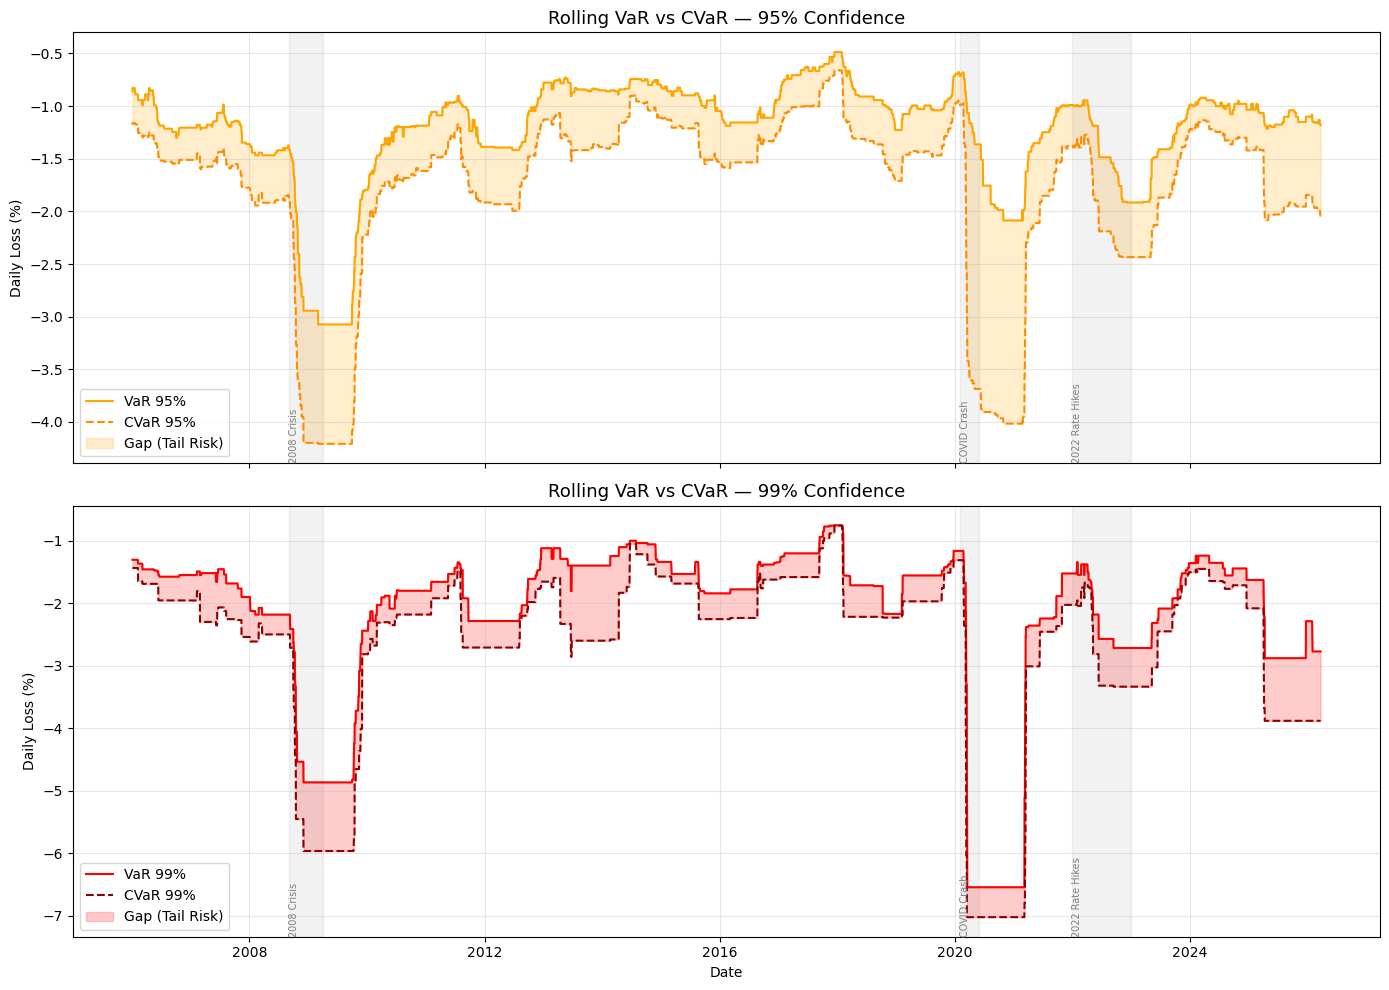

In [96]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Plot 1: 95% VaR vs CVaR ---
axes[0].plot(rolling_dates, [v * 100 for v in rolling_var_95],
             color='orange', linewidth=1.5, label='VaR 95%')
axes[0].plot(rolling_dates, [v * 100 for v in rolling_cvar_95],
             color='darkorange', linewidth=1.5, linestyle='--', label='CVaR 95%')
axes[0].fill_between(rolling_dates,
                     [v * 100 for v in rolling_var_95],
                     [v * 100 for v in rolling_cvar_95],
                     alpha=0.2, color='orange', label='Gap (Tail Risk)')
axes[0].set_title('Rolling VaR vs CVaR — 95% Confidence', fontsize=13)
axes[0].set_ylabel('Daily Loss (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: 99% VaR vs CVaR ---
axes[1].plot(rolling_dates, [v * 100 for v in rolling_var_99],
             color='red', linewidth=1.5, label='VaR 99%')
axes[1].plot(rolling_dates, [v * 100 for v in rolling_cvar_99],
             color='darkred', linewidth=1.5, linestyle='--', label='CVaR 99%')
axes[1].fill_between(rolling_dates,
                     [v * 100 for v in rolling_var_99],
                     [v * 100 for v in rolling_cvar_99],
                     alpha=0.2, color='red', label='Gap (Tail Risk)')
axes[1].set_title('Rolling VaR vs CVaR — 99% Confidence', fontsize=13)
axes[1].set_ylabel('Daily Loss (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Mark stress periods
stress_periods = {
    '2008 Crisis': ('2008-09-01', '2009-03-31'),
    'COVID Crash': ('2020-02-01', '2020-05-31'),
    '2022 Rate Hikes': ('2022-01-01', '2022-12-31')
}

for label, (start, end) in stress_periods.items():
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.1, color='grey')
        ax.text(pd.Timestamp(start), ax.get_ylim()[0],
                label, fontsize=7, color='grey', rotation=90, va='bottom')

plt.xlabel('Date')
plt.tight_layout()
plt.show()